# Australian Grand Prix 2026 – Race Analysis

This notebook analyzes the race pace, tire strategy, and driver consistency of the 
2026 Australian Grand Prix using FastF1 and Python.

Goals of this analysis:

- Load official Formula 1 timing data
- Explore lap times and race pace
- Analyze tire strategies
- Visualize performance differences between drivers

Tools used:

- FastF1
- Pandas
- Matplotlib

In [2]:
import os
import fastf1
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from fastf1 import plotting

plotting.setup_mpl()

os.makedirs('cache', exist_ok=True)

fastf1.Cache.enable_cache('cache')

In [3]:
session = fastf1.get_session(2026, 'Australia', 'R')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

In [4]:
session

2026 Season Round 1: Australian Grand Prix - Race

In [5]:
results = session.results
results[['Position', 'FullName', 'TeamName', 'Time']]

,Position,FullName,TeamName,Time
63,1.0,George Russell,Mercedes,0 days 01:23:06.801000
12,2.0,Kimi Antonelli,Mercedes,0 days 00:00:02.974000
16,3.0,Charles Leclerc,Ferrari,0 days 00:00:15.519000
44,4.0,Lewis Hamilton,Ferrari,0 days 00:00:16.144000
1,5.0,Lando Norris,McLaren,0 days 00:00:51.741000
3,6.0,Max Verstappen,Red Bull Racing,0 days 00:00:54.617000
87,7.0,Oliver Bearman,Haas F1 Team,0 days 00:00:04.593000
41,8.0,Arvid Lindblad,Racing Bulls,0 days 00:00:11.816000
5,9.0,Gabriel Bortoleto,Audi,0 days 00:00:12.775000
10,10.0,Pierre Gasly,Alpine,0 days 00:00:29.027000


In [6]:
laps = session.laps

laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True


In [7]:
laps[['Driver', 'LapNumber', 'LapTime', 'Stint', 'Compound']].head(20)

,Driver,LapNumber,LapTime,Stint,Compound
0,NOR,1.0,0 days 00:01:36.458000,1.0,MEDIUM
1,NOR,2.0,0 days 00:01:27.344000,1.0,MEDIUM
2,NOR,3.0,0 days 00:01:26.863000,1.0,MEDIUM
3,NOR,4.0,0 days 00:01:25.857000,1.0,MEDIUM
4,NOR,5.0,0 days 00:01:25.573000,1.0,MEDIUM
5,NOR,6.0,0 days 00:01:25.036000,1.0,MEDIUM
6,NOR,7.0,0 days 00:01:24.978000,1.0,MEDIUM
7,NOR,8.0,0 days 00:01:25.299000,1.0,MEDIUM
8,NOR,9.0,0 days 00:01:25.639000,1.0,MEDIUM
9,NOR,10.0,0 days 00:01:25.295000,1.0,MEDIUM


In [8]:
laps['Driver'].unique()

array(['NOR', 'GAS', 'PER', 'ANT', 'ALO', 'LEC', 'STR', 'ALB', 'HUL',
       'VER', 'LAW', 'OCO', 'LIN', 'COL', 'HAM', 'BOR', 'SAI', 'HAD',
       'RUS', 'BOT', 'BEA'], dtype=object)

In [9]:
laps_clean = laps.pick_quicklaps()

laps_clean.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True
5,0 days 01:11:07.110000,NOR,1,0 days 00:01:25.036000,6.0,1.0,NaT,NaT,0 days 00:00:30.025000,0 days 00:00:17.829000,...,True,McLaren,0 days 01:09:42.074000,2026-03-08 04:10:48.697,1,7.0,False,,False,True


In [10]:
pace = laps_clean.groupby('Driver')['LapTime'].mean().sort_values()

pace

Driver
ANT   0 days 00:01:23.377529411
HAM   0 days 00:01:23.431708333
RUS   0 days 00:01:23.485176470
LEC   0 days 00:01:23.512729166
VER   0 days 00:01:23.877795918
NOR      0 days 00:01:23.900920
BOR   0 days 00:01:24.828387755
BEA   0 days 00:01:24.982979591
LIN   0 days 00:01:25.003543478
LAW   0 days 00:01:25.210934782
GAS   0 days 00:01:25.420938775
OCO   0 days 00:01:25.448326530
HAD   0 days 00:01:25.497666666
ALB   0 days 00:01:25.548872340
SAI   0 days 00:01:25.602902439
COL   0 days 00:01:25.706113636
STR   0 days 00:01:26.645263157
ALO      0 days 00:01:26.709800
PER      0 days 00:01:26.873720
BOT   0 days 00:01:27.617166666
Name: LapTime, dtype: timedelta64[ns]

In [11]:
pace_seconds = pace.dt.total_seconds()

pace_seconds

Driver
ANT    83.377529
HAM    83.431708
RUS    83.485176
LEC    83.512729
VER    83.877796
NOR    83.900920
BOR    84.828388
BEA    84.982980
LIN    85.003543
LAW    85.210935
GAS    85.420939
OCO    85.448327
HAD    85.497667
ALB    85.548872
SAI    85.602902
COL    85.706114
STR    86.645263
ALO    86.709800
PER    86.873720
BOT    87.617167
Name: LapTime, dtype: float64

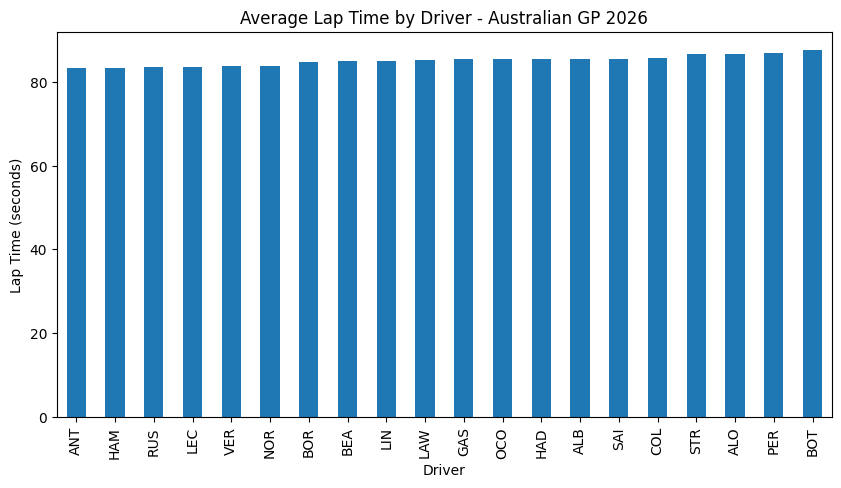

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

pace_seconds.plot(kind='bar')

plt.title('Average Lap Time by Driver - Australian GP 2026')
plt.xlabel('Driver')
plt.ylabel('Lap Time (seconds)')

plt.show()

### Race Pace Analysis

The chart above shows the average race pace for each driver after removing
slow laps and pit laps.

Key observations:

- Drivers at the top maintained the strongest race pace
- Differences between top teams appear small
- Midfield drivers show larger pace variation


In [13]:
laps_tyre = laps.pick_quicklaps().copy()

laps_tyre = laps_tyre[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife']]

In [14]:
laps_tyre['LapTimeSeconds'] = laps_tyre['LapTime'].dt.total_seconds()

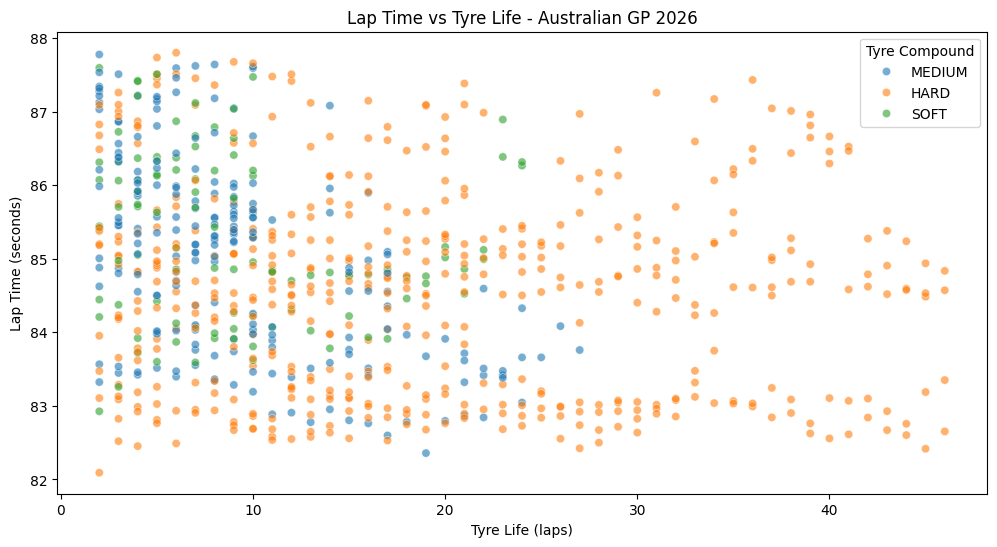

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data = laps_tyre,
    x = 'TyreLife',
    y = 'LapTimeSeconds',
    hue = 'Compound',
    alpha = 0.6
)

plt.title('Lap Time vs Tyre Life - Australian GP 2026')
plt.xlabel('Tyre Life (laps)')
plt.ylabel('Lap Time (seconds)')

plt.legend(title='Tyre Compound')
plt.show()

### Tire Degradation Analysis

Lap times tend to increase as tire life increases, which indicates degradation.

Soft tires show faster lap times but degrade more quickly,
while harder compounds maintain more consistent performance.

In [16]:
laps_box = laps_clean.copy()

laps_box['LapTimeSeconds'] = laps_box['LapTime'].dt.total_seconds()

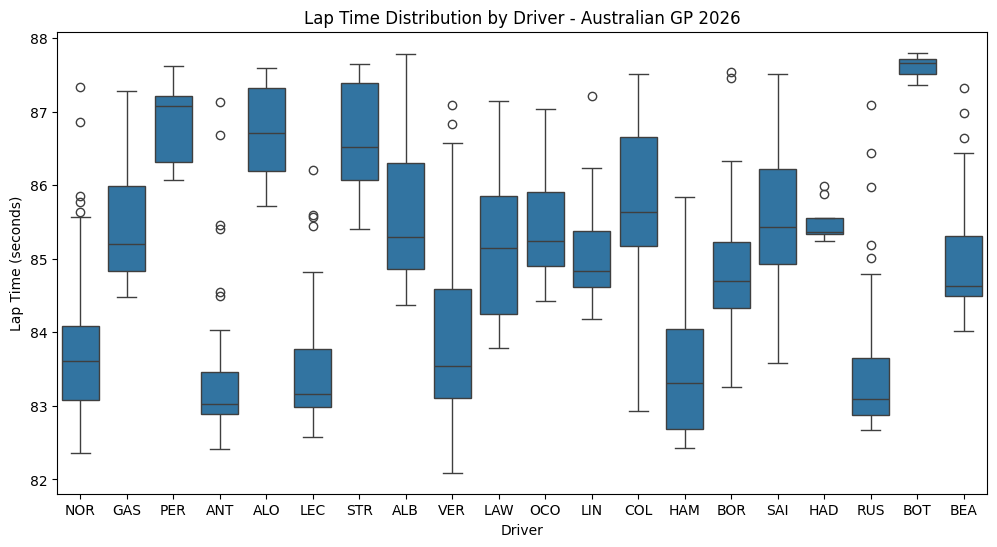

In [17]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data = laps_box,
    x = 'Driver',
    y = 'LapTimeSeconds'
)

plt.title('Lap Time Distribution by Driver - Australian GP 2026')
plt.xlabel('Driver')
plt.ylabel('Lap Time (seconds)')    

plt.show()

In [20]:
antonelli_lap = session.laps.pick_drivers('ANT').pick_fastest()
russell_lap = session.laps.pick_drivers('RUS').pick_fastest()

In [21]:
antonelli_tel = antonelli_lap.get_car_data().add_distance()
russell_tel = russell_lap.get_car_data().add_distance()

In [22]:
antonelli_tel.head()

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2026-03-08 05:23:51.586,11398.0,295.0,7,100.0,False,0,car,0 days 00:00:00.279000,0 days 02:22:44.963000,22.862500
1,2026-03-08 05:23:51.787,11412.0,297.0,7,100.0,False,0,car,0 days 00:00:00.480000,0 days 02:22:45.164000,39.445000
2,2026-03-08 05:23:51.947,11458.0,297.0,7,100.0,False,0,car,0 days 00:00:00.640000,0 days 02:22:45.324000,52.645000
3,2026-03-08 05:23:52.107,11486.0,297.0,7,100.0,False,0,car,0 days 00:00:00.800000,0 days 02:22:45.484000,65.845000
4,2026-03-08 05:23:52.307,11449.0,298.0,7,100.0,False,0,car,0 days 00:00:01,0 days 02:22:45.684000,82.400556


In [23]:
print(antonelli_tel.columns)

Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Distance'],
      dtype='object')


In [24]:
print("Antonelli max speed: ", antonelli_tel['Speed'].max())
print("Russell max speed: ", russell_tel['Speed'].max())

Antonelli max speed:  319.0
Russell max speed:  324.0


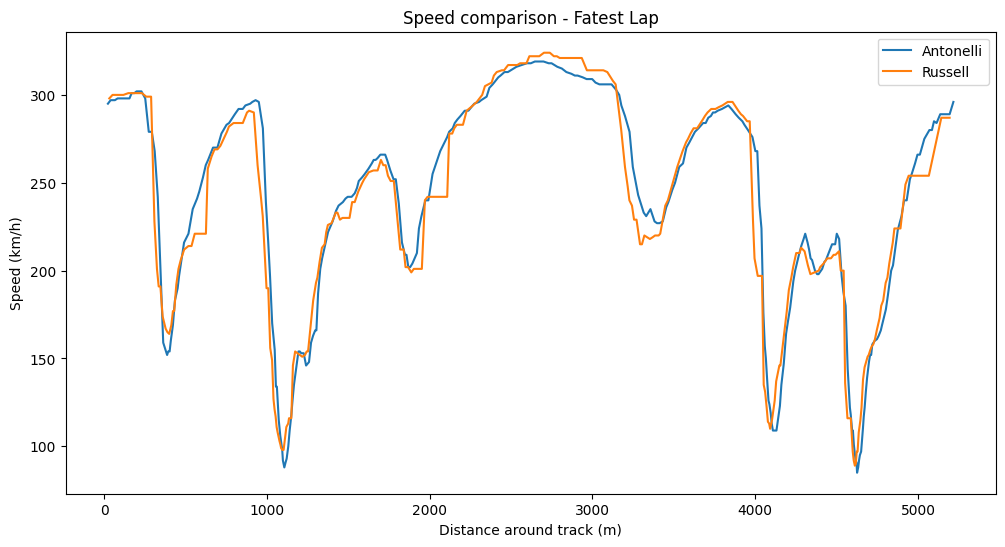

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    antonelli_tel['Distance'],
    antonelli_tel['Speed'],
    label = 'Antonelli'
)

plt.plot(
    russell_tel['Distance'],
    russell_tel['Speed'],
    label = 'Russell'
)

plt.title('Speed comparison - Fatest Lap')
plt.xlabel('Distance around track (m)')
plt.ylabel('Speed (km/h)')

plt.legend()

plt.show()

### Speed Trace Comparison

The speed trace shows how both drivers accelerate and brake around the circuit.

Differences in peak speed may indicate aerodynamic setup or power unit
performance, while differences in corner speeds reflect driving style
and car balance.

In [26]:
laps_team = laps_clean.copy()

laps_team['LapTimeSeconds'] = laps_team['LapTime'].dt.total_seconds()

In [27]:
team_laps = laps_team[laps_team['Team'].isin(['Mercedes', 'Ferrari'])]

team_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
171,0 days 01:05:24.074000,ANT,12,0 days 00:01:27.129000,2.0,1.0,NaT,NaT,0 days 00:00:30.820000,0 days 00:00:18.035000,...,Mercedes,0 days 01:03:56.945000,2026-03-08 04:05:03.568,1,7.0,False,,False,True,87.129
172,0 days 01:06:49.537000,ANT,12,0 days 00:01:25.463000,3.0,1.0,NaT,NaT,0 days 00:00:30.586000,0 days 00:00:18.042000,...,Mercedes,0 days 01:05:24.074000,2026-03-08 04:06:30.697,1,6.0,False,,False,True,85.463
173,0 days 01:08:14.948000,ANT,12,0 days 00:01:25.411000,4.0,1.0,NaT,NaT,0 days 00:00:29.869000,0 days 00:00:17.795000,...,Mercedes,0 days 01:06:49.537000,2026-03-08 04:07:56.160,1,6.0,False,,False,True,85.411
174,0 days 01:09:39.447000,ANT,12,0 days 00:01:24.499000,5.0,1.0,NaT,NaT,0 days 00:00:29.761000,0 days 00:00:18.073000,...,Mercedes,0 days 01:08:14.948000,2026-03-08 04:09:21.571,1,5.0,False,,False,True,84.499
175,0 days 01:11:03.471000,ANT,12,0 days 00:01:24.024000,6.0,1.0,NaT,NaT,0 days 00:00:29.534000,0 days 00:00:17.861000,...,Mercedes,0 days 01:09:39.447000,2026-03-08 04:10:46.070,1,4.0,False,,False,True,84.024


In [28]:
team_laps[['Driver', 'Team']].drop_duplicates()

,Driver,Team
171,ANT,Mercedes
251,LEC,Ferrari
695,HAM,Ferrari
877,RUS,Mercedes


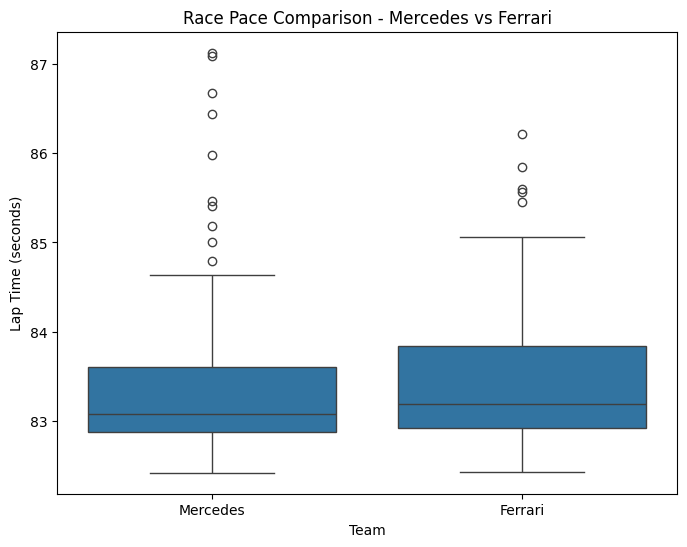

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(
    data = team_laps,
    x = 'Team',
    y = 'LapTimeSeconds'
)

plt.title('Race Pace Comparison - Mercedes vs Ferrari')
plt.xlabel('Team')
plt.ylabel('Lap Time (seconds)')

plt.show()

In [31]:
team_pace = team_laps.groupby('Team')['LapTimeSeconds'].mean().sort_values()

team_pace

Team
Mercedes    83.431353
Ferrari     83.472219
Name: LapTimeSeconds, dtype: float64

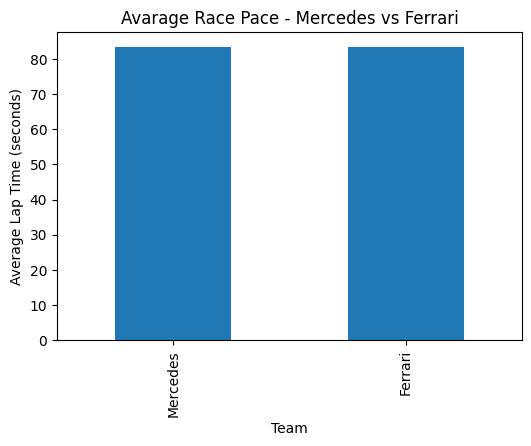

In [32]:
team_pace.plot(kind='bar', figsize=(6, 4))

plt.title("Avarage Race Pace - Mercedes vs Ferrari")
plt.ylabel("Average Lap Time (seconds)")

plt.show()

### Team Performance Comparison

Race pace was analyzed for Mercedes and Ferrari using clean laps.

The boxplot shows the distribution of lap times for both teams.
Mercedes appears to have a slightly lower median lap time,
indicating stronger race pace during the Australian Grand Prix.

In [33]:
lap = antonelli_lap

tel = lap.get_car_data().add_distance()

In [36]:
pos = antonelli_lap.get_pos_data()

In [37]:
pos.columns

Index(['Date', 'Status', 'X', 'Y', 'Z', 'Source', 'Time', 'SessionTime'], dtype='object')

In [39]:
car_data = antonelli_lap.get_car_data()
car_data = car_data.add_distance()

In [40]:
speed = car_data['Speed']

In [41]:
type(car_data)

fastf1.core.Telemetry

In [42]:
pos = antonelli_lap.get_pos_data()

x = pos['X']
y = pos['Y']

In [ ]:
car_data.columns

pos.columns

Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Distance'],
      dtype='object')